The Classic Iris Dataset

In [1]:
# Standart imports
import os

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

# Local imports

In [2]:
sns.set()

# Load data
load the Iris flower dataset using scikit-learn's built-in datasets.

In [3]:
datasets.load_iris?

In [4]:
data = datasets.load_iris()

In [5]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
print(data["DESCR"])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [7]:
data["data"][:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [8]:
data["feature_names"]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [9]:
data["target"]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
data["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## What problem are we trying to solve?
We are trying to use attributes of flowers to predict the species of the flower. Basically, we are trying to use the sepal length and width and the petal length and width to predict if a Iris flower is of type _Setosa_, _Versicolor_, or Virginica.

This is a multiclass classification problem

# Create a pandas DataFrame from the data
We coulde do our full analysis using NumPy and NumPy arrays, but we'll create a pandas DataFrame because it does make some htings simpler, and also to get some practice using pandas.

In [11]:
df = pd.DataFrame(data["data"], columns=data["feature_names"])

In [12]:
df["target"] = data["target"]

In [13]:
df.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
97,6.2,2.9,4.3,1.3,1
14,5.8,4.0,1.2,0.2,0
146,6.3,2.5,5.0,1.9,2
32,5.2,4.1,1.5,0.1,0
74,6.4,2.9,4.3,1.3,1
101,5.8,2.7,5.1,1.9,2
48,5.3,3.7,1.5,0.2,0
87,6.3,2.3,4.4,1.3,1
41,4.5,2.3,1.3,0.3,0


# Basic descriptive statistics

In [14]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Distributions of features and target

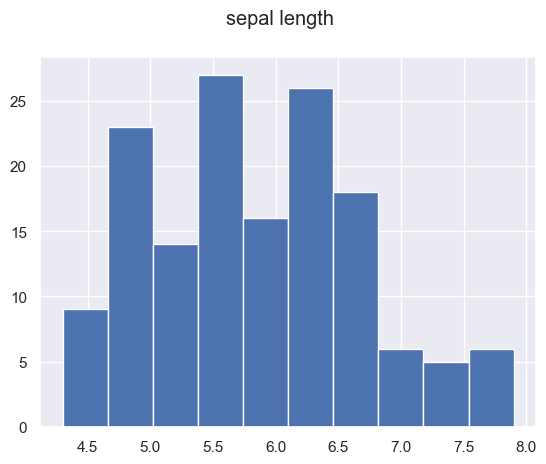

In [15]:
col = "sepal length (cm)"
df[col].hist()
plt.suptitle("sepal length")
plt.show()

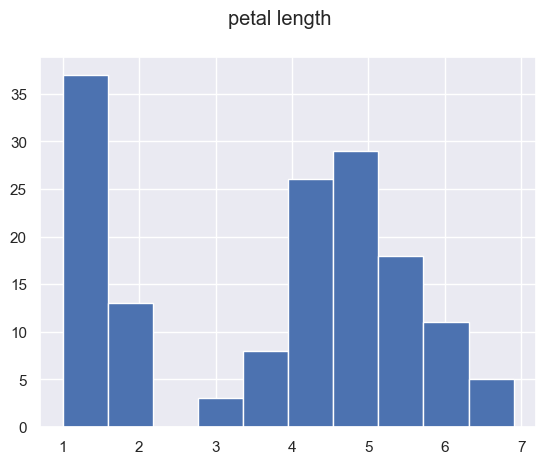

In [16]:
col = "petal length (cm)"
df[col].hist()
plt.suptitle("petal length")
plt.show()

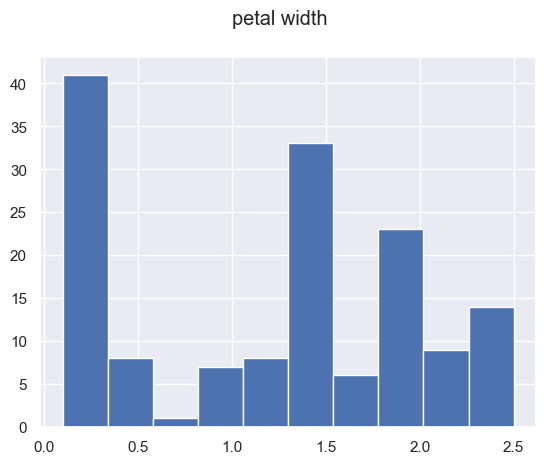

In [17]:
col = "petal width (cm)"
df[col].hist()
plt.suptitle("petal width")
plt.show()

# Relationship of the data features with the target

In [18]:
data["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [19]:
# Create new column with the species name
df["target_names"] = df["target"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


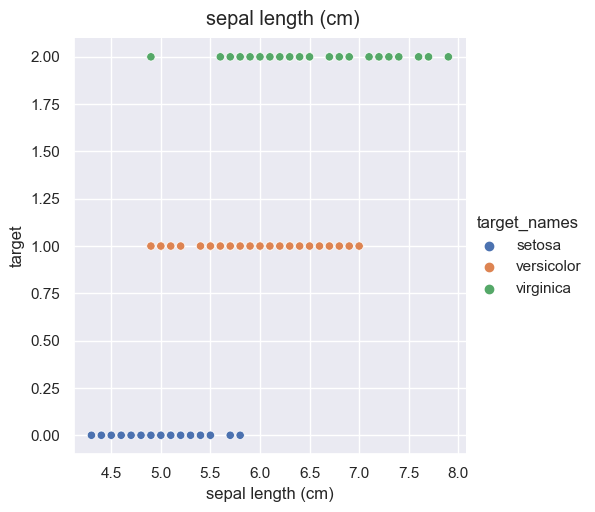

In [20]:
col = "sepal length (cm)"
sns.relplot(x=col, y="target", hue="target_names", data=df)
plt.suptitle(col, y=1.02)
plt.show()

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


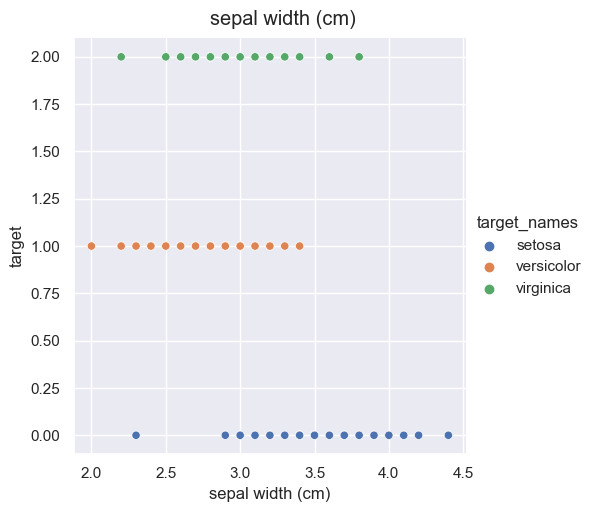

In [21]:
col = "sepal width (cm)"
sns.relplot(x=col, y="target", hue="target_names", data=df)
_ = plt.suptitle(col, y=1.02)

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


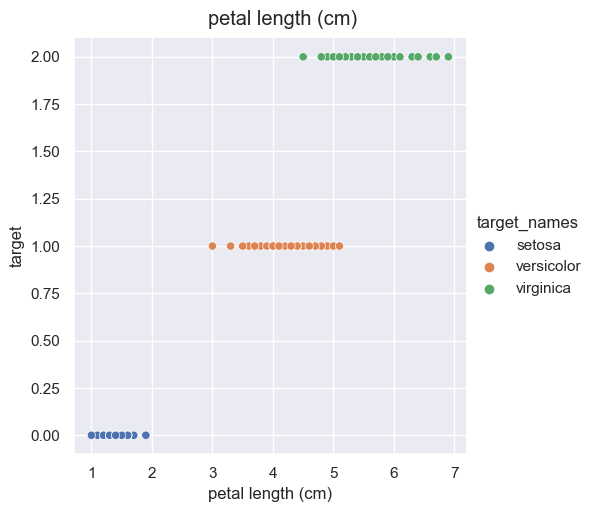

In [22]:
col = "petal length (cm)"
sns.relplot(x=col, y="target", hue="target_names", data=df)
plt.suptitle(col, y=1.02)
plt.show()

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


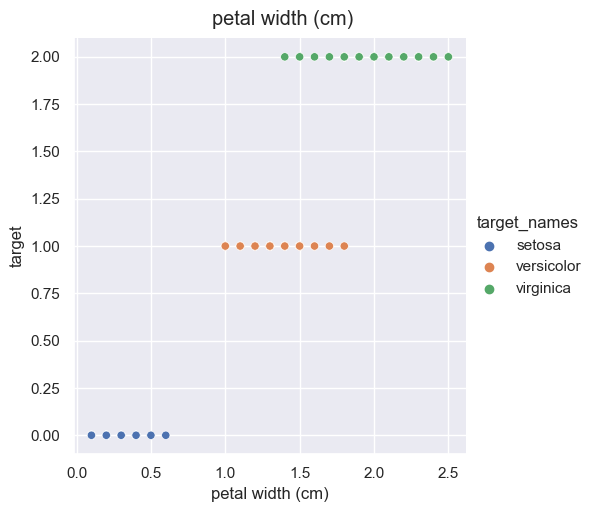

In [23]:
col = "petal width (cm)"
sns.relplot(x=col, y="target", hue="target_names", data=df)
plt.suptitle(col, y=1.02)
plt.show()

# Exploratory Data Analysis (EDA) - Pairplots

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


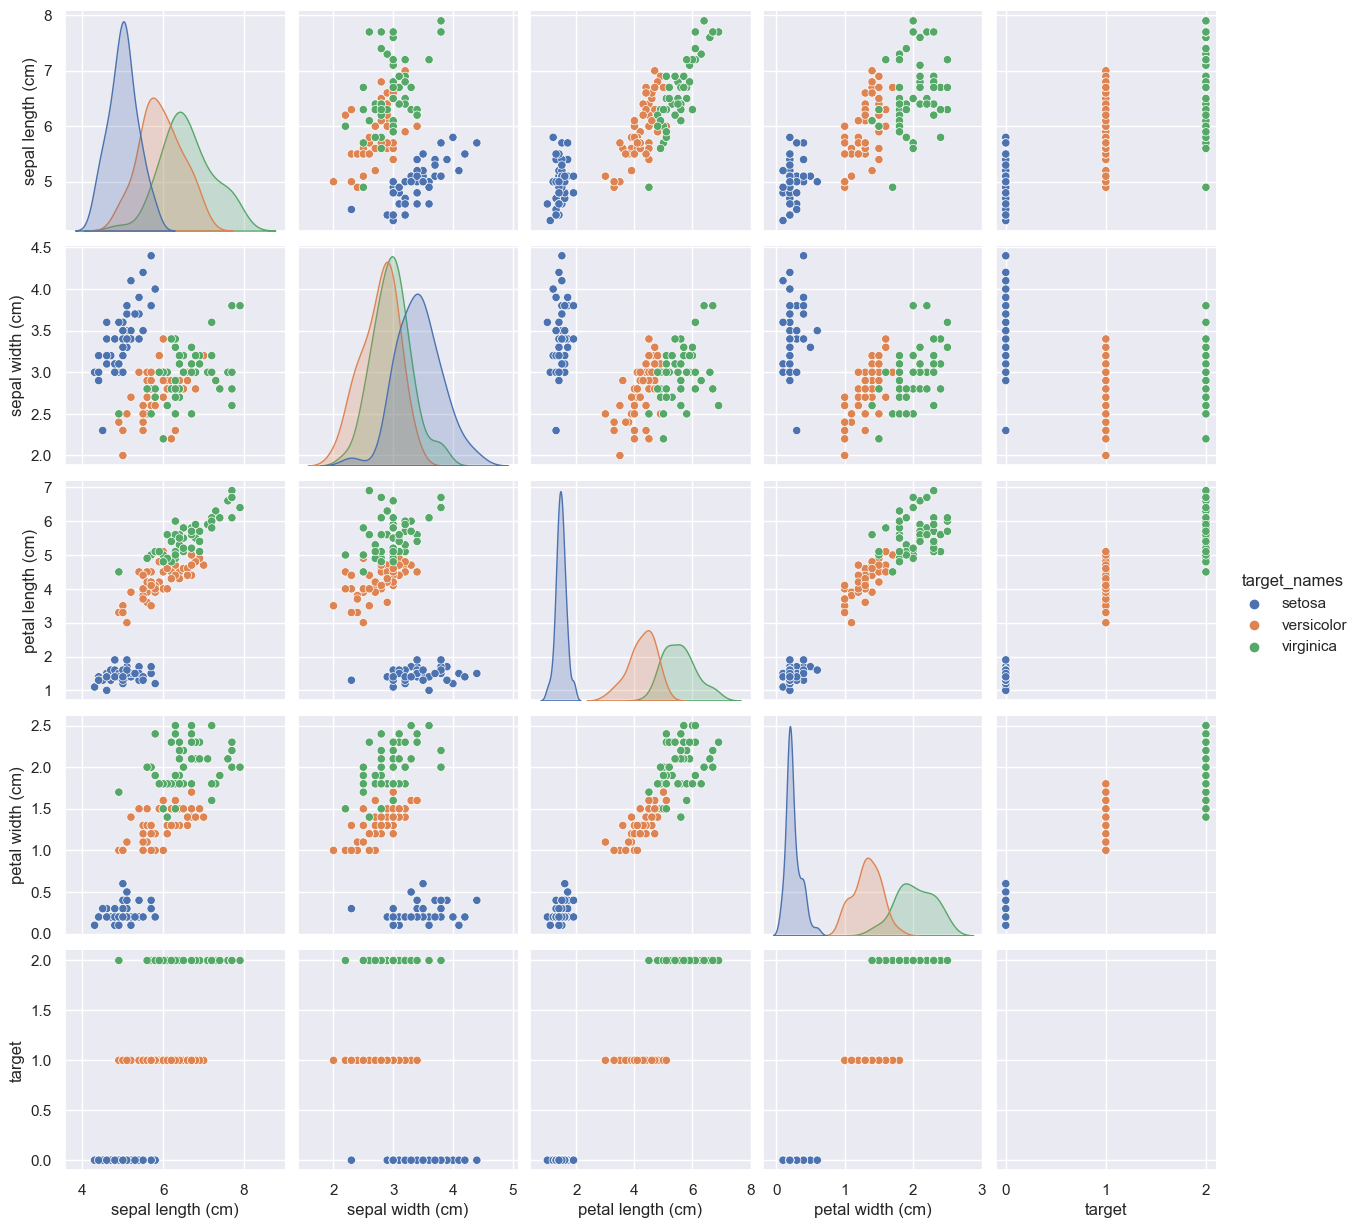

In [24]:
sns.pairplot(df, hue="target_names")

# Train Test Split
You always want to evaluate your final model on a test set that hasn't been used at all in the training process.

_(NOTE: This might be a little less true if cross-validation is used, but is still considered best practice.)_

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
df_train, df_test = train_test_split(df, test_size=0.25)

In [27]:
df_train.shape

(112, 6)

In [28]:
df_test.shape

(38, 6)

In [29]:
df_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
44,5.1,3.8,1.9,0.4,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
16,5.4,3.9,1.3,0.4,0,setosa
54,6.5,2.8,4.6,1.5,1,versicolor
71,6.1,2.8,4.0,1.3,1,versicolor


# Prepare our data for modeling
This involves splitting the data back out into plain NumPy arrays

In [30]:
X_train = df_train.drop(columns = ["target", "target_names"]).values
Y_train = df_train["target"].values

In [31]:
Y_train

array([0, 0, 0, 1, 1, 1, 2, 2, 0, 1, 2, 1, 0, 2, 0, 2, 1, 2, 0, 2, 0, 0,
       2, 1, 1, 0, 0, 2, 0, 2, 2, 2, 2, 1, 0, 1, 2, 0, 2, 0, 2, 2, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 1, 2, 2, 0, 2, 1, 1, 2, 2, 0, 1,
       0, 1, 2, 1, 1, 0, 1, 2, 2, 0, 2, 1, 0, 2, 2, 0, 1, 1, 2, 1, 0, 2,
       2, 2, 1, 2, 2, 0, 0, 1, 1, 0, 1, 0, 0, 2, 0, 1, 1, 2, 1, 1, 1, 1,
       2, 1])

# Modeling - What is our baseline?

What is the simplest model we can think of?

In this case, if our baseline model is just randomly guessing the species of flower, or guessing a single species for every data point, we would expect to have a model accuracy of 0.33 or 33&, since we have 3 different classes that are evenly balanced.

So our models should at least beat 33% accuracy.

# Modeling - Simple Manual Model

Let's manually look at our data and decide some cutoff points for classification.

In [32]:
data["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [33]:
def single_feature_prediction(petal_length):
    # Predicts the Iris species given the petal length.
    if petal_length < 2.5:
        return 0
    elif petal_length < 4.8:
        return 1
    else:
        return 2

In [34]:
X_train[:, 2]

array([1.9, 1.5, 1.3, 4.6, 4. , 4.7, 5.6, 6.1, 1.5, 4.2, 4.9, 3. , 1.4,
       5.1, 1.4, 5.5, 5. , 5.4, 1.6, 4.5, 1.3, 1.1, 5.6, 4.4, 4.6, 1.4,
       1.3, 6.7, 1.5, 5.1, 5.8, 6.1, 5.9, 4.2, 1.4, 4.7, 5. , 1.4, 5.4,
       1.5, 6.1, 5.2, 1.9, 4.2, 1.5, 1.4, 3.5, 1.2, 4.1, 1.5, 4.7, 1.5,
       3.6, 1.3, 4.9, 3.5, 4.8, 5.7, 1.6, 5.1, 4.5, 4.5, 5.1, 5. , 1.4,
       4.3, 1.4, 3.8, 5.1, 3.9, 4.7, 1.7, 3.7, 5.6, 5.5, 1.5, 5.6, 4. ,
       1.4, 5.6, 6.7, 1.5, 4.9, 4.2, 5.3, 4.4, 1.3, 5.1, 5.7, 5.2, 4. ,
       6.3, 5.3, 1.4, 1.6, 4.1, 4.9, 1.6, 4.4, 1.7, 1.3, 5. , 1.2, 3.9,
       4.5, 6.4, 4.1, 4. , 4.5, 4.5, 5.6, 4.3])

In [35]:
manula_y_predictions = np.array([single_feature_prediction(val) for val in X_train[:, 2]])

In [36]:
manual_model_accuracy =np.mean(manula_y_predictions == Y_train)

In [37]:
print(f"Manual model accuracy: {manual_model_accuracy * 100:.2f}%")

Manual model accuracy: 96.43%


# Modeling - Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression 

In [39]:
#LogisticRegression?

### Using a validation set to evaluate our model

In [40]:
model = LogisticRegression(max_iter=200)

In [41]:
# Xt stands for 'X_train' and Xv stands for 'X_validation'
Xt, Xv, Yt, Yv = train_test_split(X_train, Y_train, test_size=0.25)

In [42]:
model.fit(Xt, Yt)

LogisticRegression(max_iter=200)

In [43]:
y_pred = model.predict(Xv)

In [44]:
np.mean(y_pred == Yv)

0.9285714285714286

In [45]:
model.score(X_train, Y_train)  # don't ever evaluate your model on the same data that was used for training.

0.9821428571428571

In [46]:
model.score(Xv, Yv)

0.9285714285714286

### Using cross-validation to evaluate our model

In [47]:
from sklearn.model_selection import cross_val_score, cross_val_predict

In [48]:
model = LogisticRegression(max_iter=200)

In [49]:
accuracies = cross_val_score(model, X_train, Y_train, cv=5, scoring="accuracy")

In [50]:
np.mean(accuracies)

0.9739130434782609

# Where are we misclassifying points?

In [51]:
y_pred = cross_val_predict(model, X_train, Y_train, cv=5)

In [52]:
predicted_correctly_mask = y_pred == Y_train

In [53]:
not_predicted_correctly = ~predicted_correctly_mask

In [54]:
X_train[predicted_correctly_mask]

array([[5.1, 3.8, 1.9, 0.4],
       [5. , 3.4, 1.5, 0.2],
       [5.4, 3.9, 1.3, 0.4],
       [6.5, 2.8, 4.6, 1.5],
       [6.1, 2.8, 4. , 1.3],
       [6.1, 2.8, 4.7, 1.2],
       [6.4, 2.8, 5.6, 2.2],
       [7.2, 3.6, 6.1, 2.5],
       [5.1, 3.4, 1.5, 0.2],
       [5.7, 3. , 4.2, 1.2],
       [5.6, 2.8, 4.9, 2. ],
       [5.1, 2.5, 3. , 1.1],
       [5.1, 3.5, 1.4, 0.3],
       [5.8, 2.8, 5.1, 2.4],
       [5.5, 4.2, 1.4, 0.2],
       [6.5, 3. , 5.5, 1.8],
       [6.2, 3.4, 5.4, 2.3],
       [4.7, 3.2, 1.6, 0.2],
       [4.5, 2.3, 1.3, 0.3],
       [4.3, 3. , 1.1, 0.1],
       [6.3, 2.9, 5.6, 1.8],
       [6.6, 3. , 4.4, 1.4],
       [6.1, 3. , 4.6, 1.4],
       [5.1, 3.5, 1.4, 0.2],
       [5. , 3.5, 1.3, 0.3],
       [7.7, 3.8, 6.7, 2.2],
       [5.2, 3.5, 1.5, 0.2],
       [5.9, 3. , 5.1, 1.8],
       [6.5, 3. , 5.8, 2.2],
       [7.7, 3. , 6.1, 2.3],
       [6.8, 3.2, 5.9, 2.3],
       [5.9, 3. , 4.2, 1.5],
       [4.9, 3. , 1.4, 0.2],
       [6.1, 2.9, 4.7, 1.4],
       [5. , 3

In [55]:
X_train[not_predicted_correctly]

array([[6.7, 3. , 5. , 1.7],
       [4.9, 2.5, 4.5, 1.7],
       [6. , 2.2, 5. , 1.5]])

In [56]:
df_predictions = df_train.copy()

In [57]:
df_predictions["correct_prediction"] = predicted_correctly_mask

In [58]:
df_predictions["prediction"] = y_pred

In [59]:
df_predictions["prediction_label"] = df_predictions["prediction"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

In [60]:
df_predictions.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names,correct_prediction,prediction,prediction_label
127,6.1,3.0,4.9,1.8,2,virginica,True,2,virginica
94,5.6,2.7,4.2,1.3,1,versicolor,True,1,versicolor
44,5.1,3.8,1.9,0.4,0,setosa,True,0,setosa
51,6.4,3.2,4.5,1.5,1,versicolor,True,1,versicolor
9,4.9,3.1,1.5,0.1,0,setosa,True,0,setosa
35,5.0,3.2,1.2,0.2,0,setosa,True,0,setosa
146,6.3,2.5,5.0,1.9,2,virginica,True,2,virginica
54,6.5,2.8,4.6,1.5,1,versicolor,True,1,versicolor
89,5.5,2.5,4.0,1.3,1,versicolor,True,1,versicolor
101,5.8,2.7,5.1,1.9,2,virginica,True,2,virginica


<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

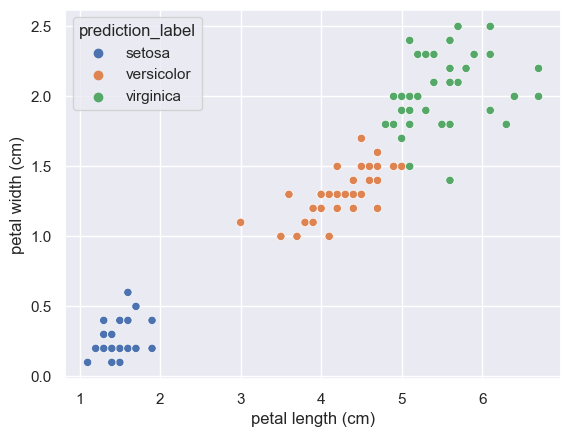

In [61]:
sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="prediction_label", data=df_predictions)

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

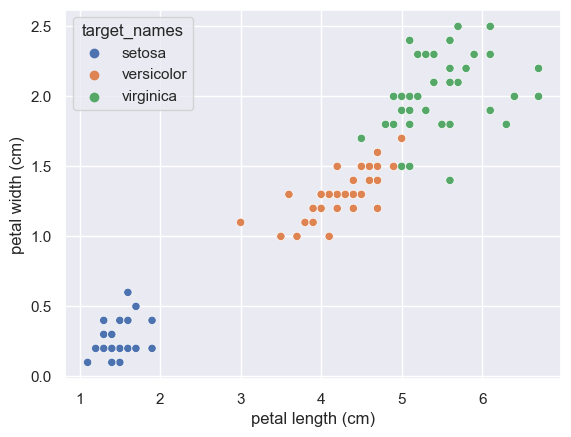

In [62]:
sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="target_names", data=df_predictions)

In [63]:
def plot_incorrect_predictions(df_predictions, x_axis_feature, y_axis_feature):
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    axs = axs.flatten()

    sns.scatterplot(
        x=x_axis_feature,
        y=y_axis_feature,
        hue="prediction_label",
        data=df_predictions,
        ax=axs[0]
    )

    sns.scatterplot(
        x=x_axis_feature,
        y=y_axis_feature,
        hue="target_names",
        data=df_predictions,
        ax=axs[1]
    )
    
    sns.scatterplot(
        x=x_axis_feature,
        y=y_axis_feature,
        hue="correct_prediction",
        data=df_predictions,
        ax=axs[2]
    )
    
    axs[3].set_visible(False)
    
    plt.show()


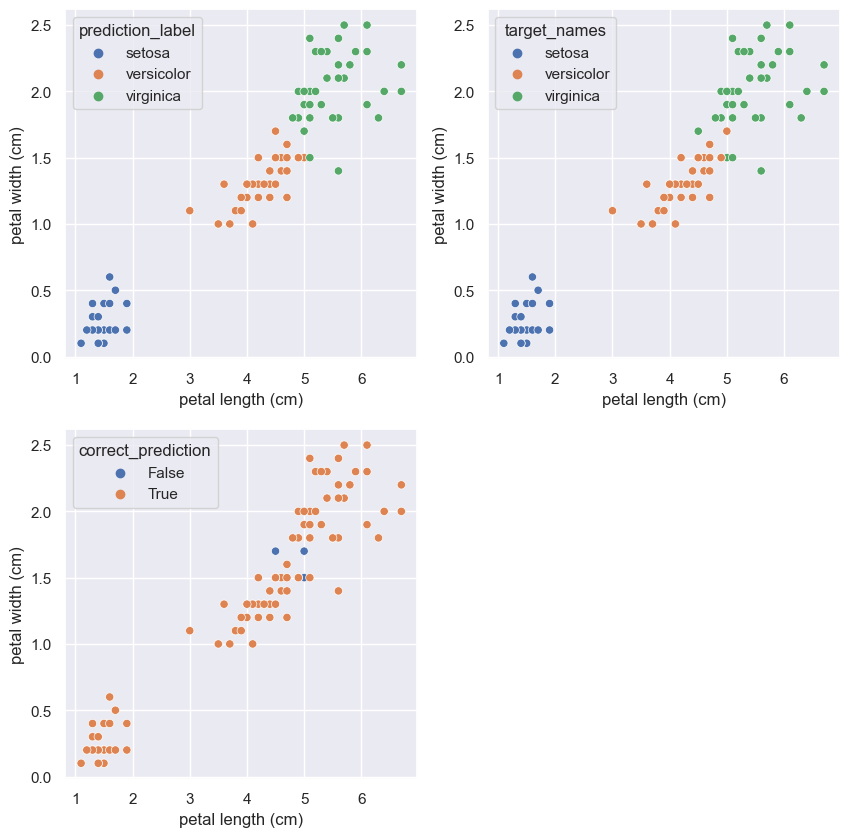

In [64]:
plot_incorrect_predictions(df_predictions, "petal length (cm)", "petal width (cm)")


# Model Tuning

What is model tuning?

Model tuning is trying to determine the parameters of your model (these are also known as "hyperparameters") that maximize the model performance.

In [85]:
for reg_param in (1, 1.3, 2, 5, 8, 8.1, 8.5, 10, 100):
    print(reg_param)
    model = LogisticRegression(max_iter=200, C=reg_param)
    accuracies = cross_val_score(model, X_train, Y_train, cv=5, scoring="accuracy")
    print(f"Accuracy: {np.mean(accuracies) * 100:.2f}%")

1
Accuracy: 97.39%
1.3
Accuracy: 97.39%
2
Accuracy: 98.26%
5
Accuracy: 98.22%
8
Accuracy: 98.22%
8.1
Accuracy: 97.31%
8.5
Accuracy: 97.31%
10
Accuracy: 97.31%
100
Accuracy: 97.31%


C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Final Model

In [86]:
model = LogisticRegression(max_iter=200, C=8)

## How well does our model do on the Test Set?

In [87]:
X_test = df_test.drop(columns = ["target", "target_names"]).values
Y_test = df_test["target"].values

In [88]:
X_test.shape

(38, 4)

In [90]:
Y_test

array([0, 0, 0, 2, 1, 1, 0, 0, 1, 1, 2, 1, 0, 2, 0, 2, 2, 0, 1, 1, 2, 0,
       1, 2, 2, 1, 0, 2, 1, 0, 1, 2, 2, 0, 1, 0, 0, 2])

### Train our final model using our full Training Dataset

In [91]:
model.fit(X_train, Y_train)

LogisticRegression(C=8, max_iter=200)

In [92]:
y_test_pred = model.predict(X_test)

In [98]:
test_set_correctly_classified = y_test_pred == Y_test
test_set_accuracy = np.mean(test_set_correctly_classified)

In [99]:
print(f"Test set accuracy: {test_set_accuracy * 100:2f}")


Test set accuracy: 94.736842


In [101]:
df_predictions_test = df_test.copy()
df_predictions_test["correct_prediction"] = test_set_correctly_classified
df_predictions_test["prediction"] = y_test_pred
df_predictions_test["prediction_label"] = df_predictions_test["prediction"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

In [102]:
df_predictions_test.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names,correct_prediction,prediction,prediction_label
47,4.6,3.2,1.4,0.2,0,setosa,True,0,setosa
112,6.8,3.0,5.5,2.1,2,virginica,True,2,virginica
118,7.7,2.6,6.9,2.3,2,virginica,True,2,virginica
30,4.8,3.1,1.6,0.2,0,setosa,True,0,setosa
83,6.0,2.7,5.1,1.6,1,versicolor,False,2,virginica
129,7.2,3.0,5.8,1.6,2,virginica,True,2,virginica
76,6.8,2.8,4.8,1.4,1,versicolor,True,1,versicolor
78,6.0,2.9,4.5,1.5,1,versicolor,True,1,versicolor
125,7.2,3.2,6.0,1.8,2,virginica,True,2,virginica
100,6.3,3.3,6.0,2.5,2,virginica,True,2,virginica


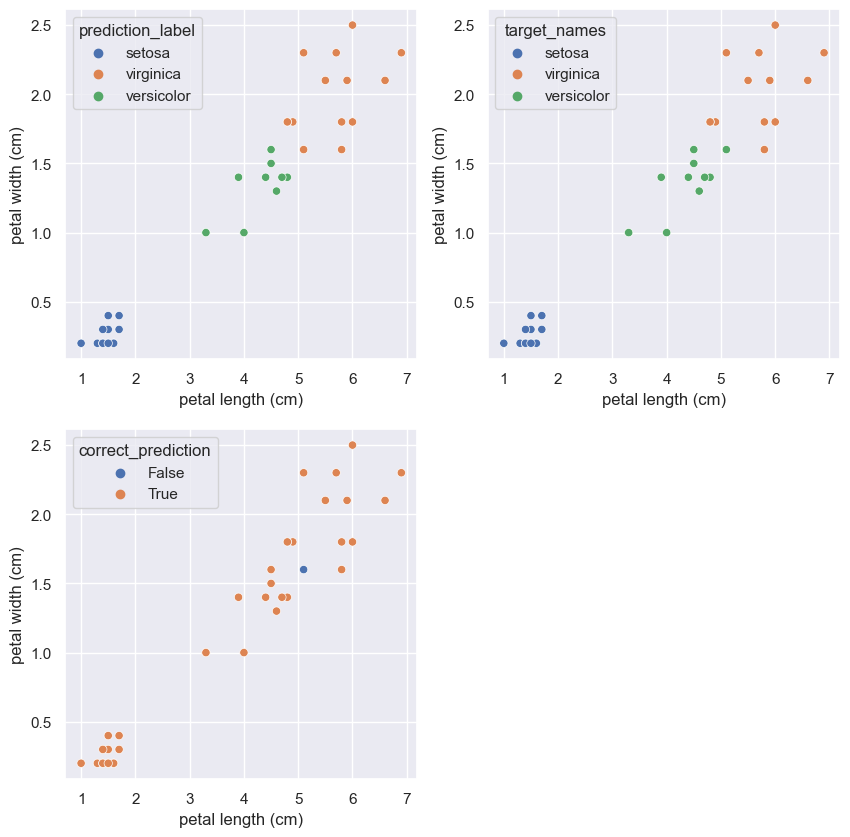

In [105]:
plot_incorrect_predictions(df_predictions_test, x_axis_feature="petal length (cm)", y_axis_feature="petal width (cm)")

In [106]:
LogisticRegression?

# In Conclusion...

In conclusion, we achieved a 94.73% accuracy on the test dataset using a Logistic Regression model with these model parameters:

'''
LogisticRegression(
    penalty='l2',
    dual=False,
    tol=0.0001,
    C=8,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=200,
    multi_class='auto',
    verbose=0,
    warm_start=False,
    n_jobs=None,
    l1_ratio=None,
)
'''